# ConvexAD: Geometrically regularized Automatic differentiation model for BCDI phase retrieval 

In [ ]:
import os
import sys
import site
import glob

# Prevent infinite restart loops
if os.environ.get('CUDA_PATHS_SET') != '1':
    nvidia_libs = []
    for sp in site.getsitepackages():
        nvidia_libs.extend(glob.glob(os.path.join(sp, 'nvidia', '*', 'lib')))
    
    if nvidia_libs:
        os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_libs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
        os.environ['CUDA_PATHS_SET'] = '1'
        
        # Replace the current kernel process with a new one inheriting the updated LD_LIBRARY_PATH
        os.execv(sys.executable, [sys.executable] + sys.argv)

# Import TF only after the restart has occurred
import tensorflow as tf
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

In [1]:
import os
import tensorflow as tf
import numpy as np
import scipy
from scipy.fft import fftshift, ifftshift, fftn
import pylab as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import hdf5plugin
import h5py

import convex_ad
from convex_ad.core import *
from convex_ad.viz import *
from convex_ad.losses import *

from tensorflow.signal import fft3d, ifft3d, ifftshift, fftshift
import colorcet as cc
print(tf.__version__)


I0000 00:00:1776692831.187706  585071 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0


In [2]:
# import tensorflow as tf
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

GPUs Available: []


# Load and visualize the data

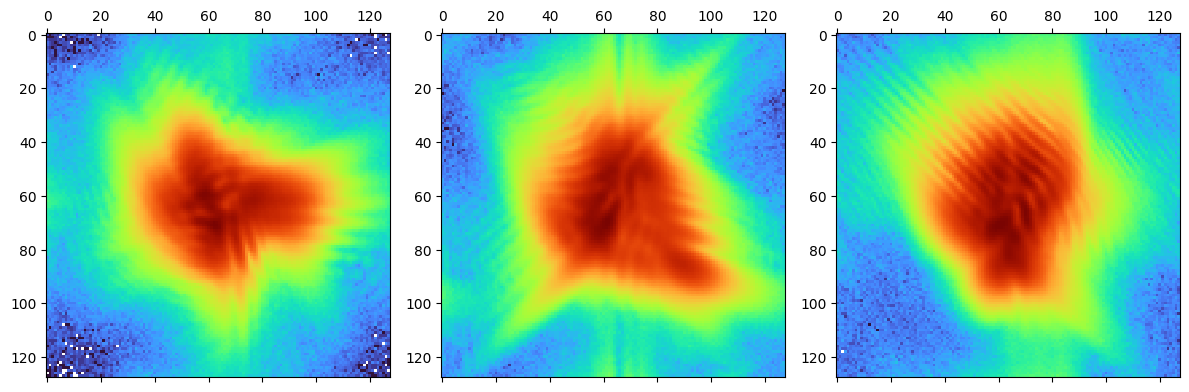

In [3]:
Iobs = np.load("data_prova.npz")["I"]
plot_3D_projections(Iobs, cmap = 'turbo')

`bs` is the batch_size, i.e. the number of objects automatically optimized in parallel by Tensorflow. Carefull not to saturate the memory. For large datasets it's better to reduce `bs` to 1 or 2 (e.g. 2x200x200x200)

# Define the model

**phase_type**: can be either `grid` for generic tensor (advised for large data or not too hard PR) or `phasor` a (sin, cos) parametrization of the phase. It takes more memory but behaves better in the optimization.

**N** is the number of *half-space* vectors used to define the support. For each of them the length *d* and the orientation vector *n* in S^2 space is optimized. A plane is built at distance *d* from the origin and the support is found by the intersection of all the planes. **eps_init** is a parameter of the sigmoid that defines the *resolution* of the reconstruction. Higher **eps_init** means lower resolution and vice versa. **size_factor** is a parameter that is used to tune the support extent during the initialization.

**grid_shape** is by default `(Iobs.shape[0]//2, Iobs.shape[1]//2, Iobs.shape[2]//2)` as it assumes the oversampling condition satisfied. It can be be passed for custom shapes. 

In [3]:
bs = 8

model = convex_ad.PhaseRetrievalModel(
    Iobs,
    bs,
    phase_type='phasor',                                                  
    support_kwargs={'N':64, 'eps':1.6, 'size_factor': 5.5},  
)

support, amp, phase = model(Iobs)

# Optimizer hyperparameters

**init_lr** is the initial learning rate. It controls how fast the algorithms is driven towards the minimum. Typical values are in the range (0.5 - 0.01)

In [5]:
init_lr = 0.05

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=init_lr,
    decay_steps=500,       
    decay_rate=0.9,        
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    beta_1=0.9,            
    beta_2=0.98,           
    epsilon=1e-6,          
    amsgrad=True,         
)

_ = model(None)
optimizer.apply_gradients([(tf.zeros_like(v), v) for v in model.trainable_variables])



<Variable path=adam/iteration, shape=(), dtype=int64, value=1>

# Initialize the coefficient

- `alpha_small` is a coefficient that penalizes large supports. Usually between 0.01 and 0.1
- `beta_tv` is a coefficient that forces the object's phase to be smooth. Better to start with 0.0 and in case regulate later. Normally a small support naturally forces smooth phases at the same time.

In [6]:

alpha_small = 0.0
beta_tv = 0.0
noise_scale = 0.0

In [7]:
from tensorflow.signal import fft3d, ifft3d, fftshift, ifftshift

fourier = fourier_loss(support, amp, phase, Iobs, metric = 'mae').numpy()
alpha_small = alpha_small*fourier/small_support(support).numpy()  
beta_tv = beta_tv*fourier/tv_loss_phase(phase).numpy()  


In [8]:
fourier = fourier_loss(support, amp, phase, Iobs).numpy()

print('Fourier loss: ', np.mean(fourier))
print('Small support loss: ', np.mean(alpha_small * small_support(support).numpy()))
print('TV phase loss: ', np.mean(beta_tv * tv_loss_phase(phase).numpy()))


Fourier loss:  318.2823
Small support loss:  0.0
TV phase loss:  0.0


In [9]:
# model.supporter.eps.assign(1.8)

# Run the optimization 

In [10]:
n_steps = 10000

loss_history = []
for step in range(n_steps):

    loss = convex_ad.train_step(
        model,
        Iobs,
        optimizer,
        alpha_small=alpha_small,
        beta_tv=beta_tv,
        noise_scale=noise_scale,
        metric = 'mae'
    )

    loss_val = float(loss.numpy())
    loss_history.append(loss_val)

    if step % 100 == 0:
        print(f"step={step:5d} | loss={loss_val:.6e}")

step=    0 | loss=3.182823e+02


KeyboardInterrupt: 

# Visualize the results

In [ ]:
support, amplitude, phase = model()

idx = np.argmin(convex_ad.fourier_loss(support, amplitude, phase, Iobs).numpy())

support = support.numpy()[idx]
amplitude = amplitude.numpy()[idx]

if isinstance(phase, tuple):
    c, s = phase
    phase = np.arctan2(s.numpy()[idx], c.numpy()[idx])
else:
    phase = phase.numpy()[idx]

obj = amplitude * support * np.exp(1j * phase)

obj_shp = tf.shape(obj)
obs_shp = tf.shape(Iobs)

dD = obs_shp[0] - obj_shp[1]
dH = obs_shp[1] - obj_shp[2]
dW = obs_shp[2] - obj_shp[3]

pD0 = dD // 2; pD1 = dD - pD0
pH0 = dH // 2; pH1 = dH - pH0
pW0 = dW // 2; pW1 = dW - pW0

obj_p = tf.pad(obj, [[0,0],[pD0,pD1],[pH0,pH1],[pW0,pW1]])

# --- FFT ---
Icalc = tf.abs(tf.signal.ifftshift(
    tf.signal.fft3d(tf.signal.fftshift(obj_p))
    
)**2

plot_3D_projections(Icalc, log_scale=True)
plot_2D_slices_middle_only_phase(obj)

# Adjust in case of binning

In [108]:
shape_binned = ((Iobs.shape[0] + bins[0] - 1) // bins[0],(Iobs.shape[1] + bins[1] - 1) // bins[1],(Iobs.shape[2] + bins[2] - 1) // bins[2])
amp_padded = scipy.fft.ifftshift(scipy.fft.fftn(scipy.fft.fftshift(final_obj)))     # 90,130,90
amp_padded2 = symmetric_pad_or_crop(amp_padded, shape_binned)       # 141,135,141 
final_obj = scipy.fft.ifftshift(scipy.fft.ifftn(scipy.fft.fftshift(amp_padded2)))

final_obj = symmetric_pad_or_crop(final_obj, Iobs.shape)


# Refine the object with Iobs

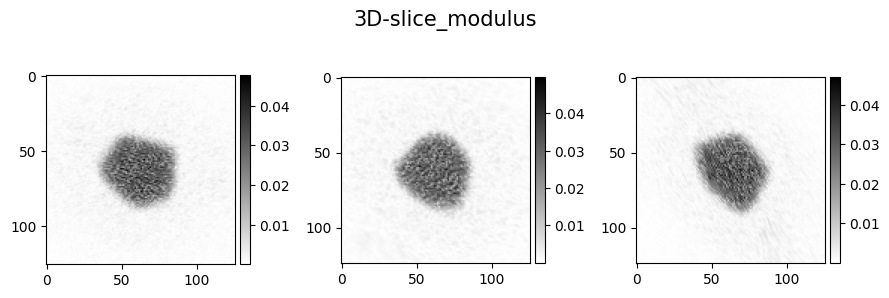

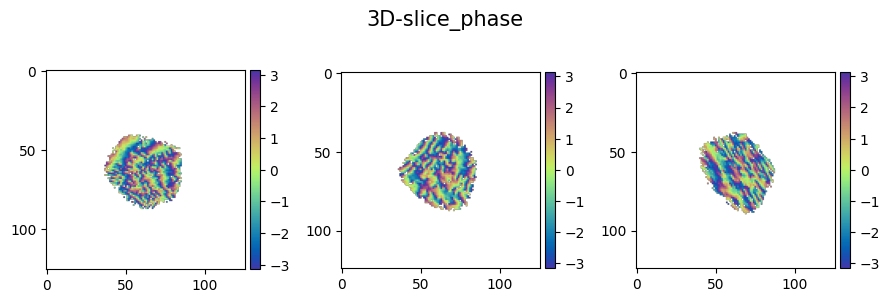

In [109]:
obje = project(final_obj, Iobs)
plot_2D_slices_middle_only_module(obje, fig_title='3D-slice_modulus')
plot_2D_slices_middle_only_phase(obje, fig_title='3D-slice_phase', unwrap = False)

In [110]:
save_model_npz(model, "pr_model_edo_big_12.npz")
